In [1]:
import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from mlflow.models import infer_signature

from catboost import CatBoostRegressor
import optuna
import shap

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

/media/sda1/repositories/house-prices/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
data = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# MLflow setup
experiment_name = "house_prices"
mlflow.set_tracking_uri("http://localhost:8080")
mlflow.set_experiment(experiment_name)

# Prepare train/val split
X = data.drop(columns=["SalePrice", "Id"])
y = np.log(data["SalePrice"])
X_test = test.drop(columns=["Id"])
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 1. Data Preprocessing Pipeline

In [3]:
num_cols = X.select_dtypes(include=["number"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

special_num_cols = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
other_num_cols = [col for col in num_cols if col not in special_num_cols]

masvnr_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

lotfront_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

def garageyr_imputer(X):
    X_filled = X.copy()
    median_year = X['YearBuilt'].median()
    X_filled['GarageYrBlt'] = X_filled['GarageYrBlt'].fillna(median_year)
    return X_filled

garage_tf = Pipeline([
    ("imputer", FunctionTransformer(garageyr_imputer))
])

other_num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("lotfront", lotfront_tf, ['LotFrontage']),
    ("masvnr", masvnr_tf, ['MasVnrArea']),
    ("garage", garage_tf, ['GarageYrBlt', 'YearBuilt']),
    ("other_num", other_num_tf, other_num_cols),
    ("cat", cat_tf, cat_cols)
])

## 2. Model Training with Optuna Hyperparameter Tuning

In [4]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 7),
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "task_type": "CPU",
        "verbose": 0
    }

    model = CatBoostRegressor(**params)
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    return - np.mean(scores)

study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="optuna_catboost"):
    study.optimize(objective, n_trials=25) 
    
    best_params = study.best_params
    best_rmse = study.best_value
    mlflow.log_metrics({"best_rmse": best_rmse})

    
    best_model = CatBoostRegressor(**best_params)
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", best_model)
    ])
    pipeline.fit(X_train, y_train)

    input_example = X_train.sample(5)
    signature = infer_signature(input_example, pipeline.predict(input_example))

    mlflow.sklearn.log_model(
        pipeline,
        name="optuna_catboost",
        signature=signature,
        input_example=input_example
    )
    
    eval_data = pd.DataFrame(X_val, columns=X.columns)
    eval_data["SalePrice"] = y_val

    model_uri = f"runs:/{mlflow.active_run().info.run_id}/optuna_catboost"
    result = mlflow.models.evaluate(
        model_uri,
        eval_data,
        targets="SalePrice",
        model_type="regressor"
    )

print("Best params:", best_params)
print("Best CV RMSE:", best_rmse)
print("Evaluation metrics:", result.metrics)


[I 2026-01-10 10:53:04,154] A new study created in memory with name: no-name-0f99f6e7-1182-48eb-aabc-64d86ee4a3d6


[I 2026-01-10 10:54:04,401] Trial 0 finished with value: 0.12926173973210942 and parameters: {'learning_rate': 0.0866279952085105, 'depth': 6, 'l2_leaf_reg': 3.0693636651510956, 'iterations': 1428}. Best is trial 0 with value: 0.12926173973210942.
[I 2026-01-10 10:57:13,216] Trial 1 finished with value: 0.13159516424067882 and parameters: {'learning_rate': 0.022885739721168898, 'depth': 9, 'l2_leaf_reg': 1.8887725765054069, 'iterations': 1806}. Best is trial 0 with value: 0.12926173973210942.
[I 2026-01-10 10:57:22,008] Trial 2 finished with value: 0.1298823171271145 and parameters: {'learning_rate': 0.07538120904732468, 'depth': 4, 'l2_leaf_reg': 2.5471305157351662, 'iterations': 789}. Best is trial 0 with value: 0.12926173973210942.
[I 2026-01-10 10:57:58,172] Trial 3 finished with value: 0.1298614720513844 and parameters: {'learning_rate': 0.09921581569603771, 'depth': 7, 'l2_leaf_reg': 3.372273379531607, 'iterations': 1008}. Best is trial 0 with value: 0.12926173973210942.
[I 2026-

0:	learn: 0.3830448	total: 51.3ms	remaining: 1m 4s
1:	learn: 0.3753367	total: 56.3ms	remaining: 35.1s
2:	learn: 0.3679206	total: 61ms	remaining: 25.4s
3:	learn: 0.3608797	total: 65.8ms	remaining: 20.5s
4:	learn: 0.3547089	total: 69.9ms	remaining: 17.4s
5:	learn: 0.3478229	total: 74.6ms	remaining: 15.4s
6:	learn: 0.3412225	total: 80ms	remaining: 14.2s
7:	learn: 0.3350087	total: 84.8ms	remaining: 13.1s
8:	learn: 0.3290853	total: 89.4ms	remaining: 12.3s
9:	learn: 0.3234159	total: 93.6ms	remaining: 11.6s
10:	learn: 0.3177856	total: 97.8ms	remaining: 11s
11:	learn: 0.3122307	total: 105ms	remaining: 10.8s
12:	learn: 0.3065058	total: 109ms	remaining: 10.4s
13:	learn: 0.3011598	total: 112ms	remaining: 9.87s
14:	learn: 0.2959037	total: 117ms	remaining: 9.63s
15:	learn: 0.2909378	total: 121ms	remaining: 9.31s
16:	learn: 0.2860605	total: 123ms	remaining: 8.93s
17:	learn: 0.2809348	total: 126ms	remaining: 8.6s
18:	learn: 0.2765415	total: 128ms	remaining: 8.3s
19:	learn: 0.2719067	total: 135ms	rema

/media/sda1/repositories/house-prices/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/media/sda1/repositories/house-prices/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing v

🏃 View run optuna_catboost at: http://localhost:8080/#/experiments/750670933042861254/runs/a15725a815dc4ae5bc0914e794cb414d
🧪 View experiment at: http://localhost:8080/#/experiments/750670933042861254
Best params: {'learning_rate': 0.0312072193755956, 'depth': 5, 'l2_leaf_reg': 1.1383337260568305, 'iterations': 1249}
Best CV RMSE: 0.12593892793331984
Evaluation metrics: {'score': np.float64(0.9069978187221353), 'example_count': 292, 'mean_absolute_error': 0.08509749391905386, 'mean_squared_error': 0.01735546425299084, 'root_mean_squared_error': 0.13174013911101978, 'sum_on_target': np.float64(3503.3129158965576), 'mean_on_target': np.float64(11.997646972248484), 'r2_score': 0.9069978187221353, 'max_error': 0.8173386498032684, 'mean_absolute_percentage_error': 0.0071722448866272945}


## 3. Feature Importance Analysis

In [5]:
def get_feature_names(column_transformer):
    feature_names = []

    for name, transformer, columns in column_transformer.transformers_:
        if transformer == 'drop' or transformer == 'passthrough':
            continue

        if hasattr(transformer, 'get_feature_names_out'):
            try:
                names = transformer.get_feature_names_out(columns)
            except:
                names = columns
        else:
            names = columns

        feature_names.extend(names)

    return feature_names

feature_names = get_feature_names(pipeline.named_steps["preprocess"])
catboost_model = pipeline.named_steps["model"]
importances = catboost_model.get_feature_importance()

feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importances.head(15)

,feature,importance
6,OverallQual,17.722801
17,GrLivArea,15.138121
14,1stFlrSF,4.281036
13,TotalBsmtSF,4.146596
26,GarageCars,4.137144
5,LotArea,3.771506
10,BsmtFinSF1,3.552346
25,Fireplaces,3.223669
8,YearBuilt,3.074800
27,GarageArea,2.789850


**Note**: Keep only the 10 most important features for the final model

In [13]:
top_features = feature_importances.head(10)["feature"]
top_features

6     OverallQual
17      GrLivArea
14       1stFlrSF
13    TotalBsmtSF
26     GarageCars
5         LotArea
10     BsmtFinSF1
25     Fireplaces
8       YearBuilt
27     GarageArea
Name: feature, dtype: object

## 4. Simplified Model with Top Features

In [14]:
num_top = [col for col in top_features if col in X.select_dtypes(include=["number"]).columns]
cat_top = [col for col in top_features if col in X.select_dtypes(include=["object"]).columns]

num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_top = ColumnTransformer([
    ("num", num_tf, num_top),
    ("cat", cat_tf, cat_top)
])

final_pipeline_top = Pipeline([
    ("preprocess", preprocess_top),
    ("model", CatBoostRegressor(**best_params))
])

final_pipeline_top.fit(X_train[top_features], y_train)

0:	learn: 0.3825065	total: 3.01ms	remaining: 3.75s
1:	learn: 0.3744945	total: 4.11ms	remaining: 2.56s
2:	learn: 0.3668010	total: 5.08ms	remaining: 2.11s
3:	learn: 0.3592912	total: 6.52ms	remaining: 2.03s
4:	learn: 0.3521138	total: 9.19ms	remaining: 2.29s
5:	learn: 0.3452729	total: 11.8ms	remaining: 2.45s
6:	learn: 0.3383313	total: 14.7ms	remaining: 2.61s
7:	learn: 0.3313996	total: 15.7ms	remaining: 2.43s
8:	learn: 0.3253442	total: 17.3ms	remaining: 2.38s
9:	learn: 0.3191352	total: 18.5ms	remaining: 2.29s
10:	learn: 0.3131561	total: 19.5ms	remaining: 2.19s
11:	learn: 0.3079731	total: 20.6ms	remaining: 2.12s
12:	learn: 0.3024544	total: 22ms	remaining: 2.09s
13:	learn: 0.2969847	total: 24.3ms	remaining: 2.14s
14:	learn: 0.2919091	total: 26.1ms	remaining: 2.15s
15:	learn: 0.2868365	total: 27.8ms	remaining: 2.14s
16:	learn: 0.2822300	total: 29.4ms	remaining: 2.13s
17:	learn: 0.2775876	total: 31.2ms	remaining: 2.13s
18:	learn: 0.2733801	total: 33.2ms	remaining: 2.15s
19:	learn: 0.2691219	tot

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5. Price Prediction Function and Analysis

In [15]:
def predict_price(form_input, pipeline):
    df = pd.DataFrame([form_input])
    y_pred_log = pipeline.predict(df)[0]
    return np.exp(y_pred_log)

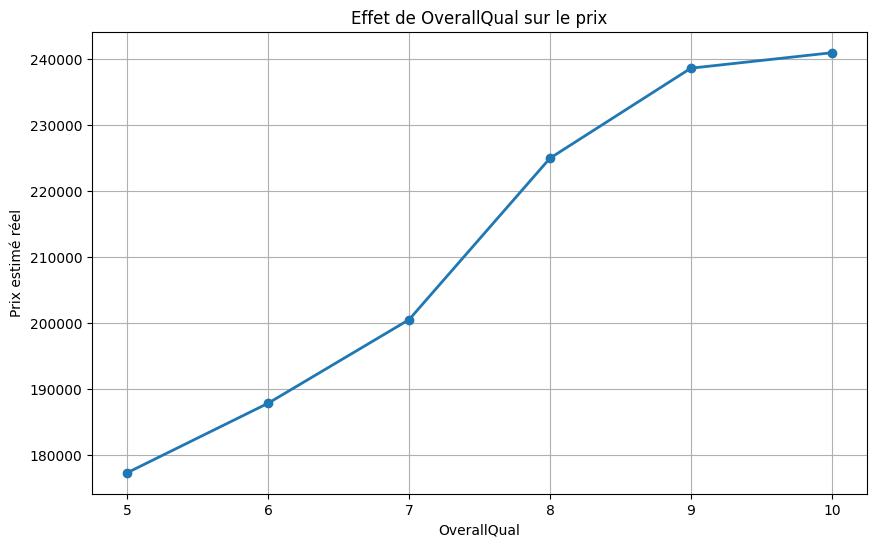

In [16]:
# Analyze impact of OverallQual on price
base_form = {
    "OverallQual": 7,
    "GrLivArea": 1500,
    "1stFlrSF": 1200,
    "Fireplaces": 1,
    "TotalBsmtSF": 900,
    "GarageArea": 400,
    "BsmtFinSF1": 600,
    "GarageCars": 2,
    "LotArea": 8000,
    "YearBuilt": 2005,
    "YearRemodAdd": 2010,
    "OverallCond": 8
}

qualities = range(5, 11)
prices = []

for q in qualities:
    form = base_form.copy()
    form["OverallQual"] = q
    price = predict_price(form, final_pipeline_top)
    prices.append(price)

plt.figure(figsize=(10, 6))
plt.plot(qualities, prices, marker='o', linewidth=2)
plt.xlabel("OverallQual")
plt.ylabel("Prix estimé réel")
plt.title("Effet de OverallQual sur le prix")
plt.grid(True)
plt.show()

## 6. Test Predictions and Submission

In [17]:
test_preds_log = final_pipeline_top.predict(X_test[top_features])
test_preds = np.exp(test_preds_log)

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_preds
})

submission.to_csv("data/submission.csv", index=False)

print(f"Min: {test_preds.min():.2f}, Max: {test_preds.max():.2f}, Mean: {test_preds.mean():.2f}")

Min: 46408.94, Max: 518065.43, Mean: 177213.89


## 7. Data Summary

In [18]:
print("Training data statistics:")
print(data["SalePrice"].describe())
print("\nTest predictions statistics:")
print(pd.Series(test_preds).describe())

Training data statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Test predictions statistics:
count      1459.000000
mean     177213.891778
std       75107.381778
min       46408.936015
25%      127747.659964
50%      156685.510841
75%      207173.371288
max      518065.429406
dtype: float64
